<a href="https://colab.research.google.com/github/juliazelena/Data-Visualization-with-Matplotlib/blob/main/Data_Visualization_with_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/My Drive/Mate academy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/Mate academy


In [ ]:
sales_data = pd.read_csv("sales_data_updated.csv")
sales_data.head()

,order_date,time,aging,customer_id,gender,device_type,customer_login_type,product_category,product,sales,quantity,discount,profit,shipping_cost,order_priority,payment_method
0,2018-01-01,10:11:40,5.0,29317,Male,Web,Member,Auto & Accessories,Car Media Players,140.0,4.0,0.3,43.2,4.3,Medium,e_wallet
1,2018-01-01,22:30:44,7.0,42270,Male,Web,Member,Auto & Accessories,Car Pillow & Neck Rest,231.0,5.0,0.1,139.5,13.9,High,money_order
2,2018-01-01,21:55:31,10.0,14563,Male,Web,Member,Auto & Accessories,Car Speakers,211.0,5.0,0.1,120.5,12.0,High,credit_card
3,2018-01-01,13:57:15,9.0,58601,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.2,150.0,15.0,Critical,credit_card
4,2018-01-01,15:17:41,2.0,48342,Male,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.1,165.0,16.5,High,credit_card


In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_date           51290 non-null  object 
 1   time                 51290 non-null  object 
 2   aging                51289 non-null  float64
 3   customer_id          51290 non-null  int64  
 4   gender               51290 non-null  object 
 5   device_type          51290 non-null  object 
 6   customer_login_type  51290 non-null  object 
 7   product_category     51290 non-null  object 
 8   product              51290 non-null  object 
 9   sales                51289 non-null  float64
 10  quantity             51288 non-null  float64
 11  discount             51289 non-null  float64
 12  profit               51290 non-null  float64
 13  shipping_cost        51289 non-null  float64
 14  order_priority       51288 non-null  object 
 15  payment_method       51290 non-null 

In [ ]:
missing_counts = sales_data.isnull().sum()
print(missing_counts)

order_date             0
time                   0
aging                  0
customer_id            0
gender                 0
device_type            0
customer_login_type    0
product_category       0
product                0
sales                  0
quantity               2
discount               1
profit                 0
shipping_cost          1
order_priority         0
payment_method         0
dtype: int64


In [ ]:
sales_data["aging"] = sales_data["aging"].fillna(sales_data["aging"].median())
sales_data["sales"] = sales_data["sales"].fillna(sales_data["sales"].mean())
sales_data["order_priority"] = sales_data["order_priority"].fillna(sales_data["order_priority"].mode()[0])

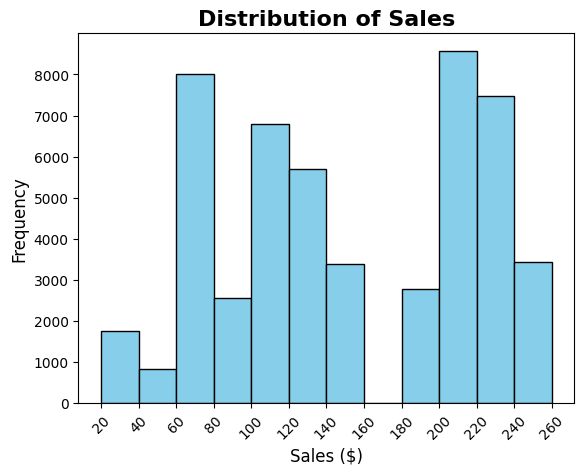

In [ ]:
sales = sales_data["sales"]

bin_edges = np.arange(sales.min() - 13, sales.max() + 20, 20)

plt.hist(sales_data["sales"], bins=bin_edges, color="skyblue", edgecolor="black")

plt.title("Distribution of Sales", fontsize=16, fontweight="bold")
plt.xlabel("Sales ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xticks(bin_edges, rotation=45)
plt.show()

Згідно з гістограмою, найбільше продажів припадає на інтервал 200–220 $.  Розподіл має позитивну асиметрію (зсунутий вправо).


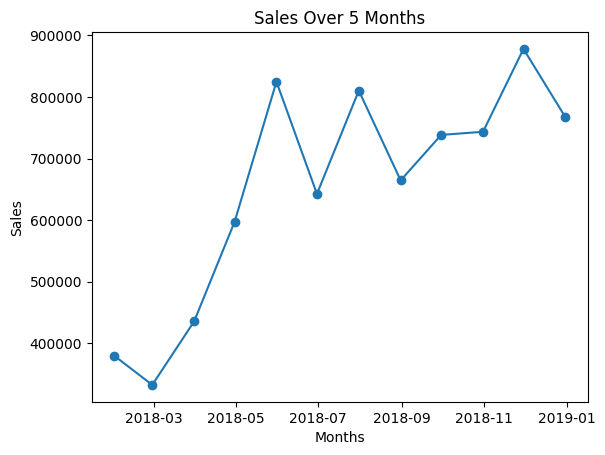

In [ ]:
sales_data["order_date"] = pd.to_datetime(sales_data["order_date"])
grouped_by_month = sales_data.groupby(pd.Grouper(key="order_date", freq="ME"))["sales"].sum()

plt.plot(grouped_by_month.index, grouped_by_month.values, marker="o")
plt.title("Sales Over 5 Months")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

Кількість продажів зростає з часом, також спостерігаємо незначні спади у липні та вересні

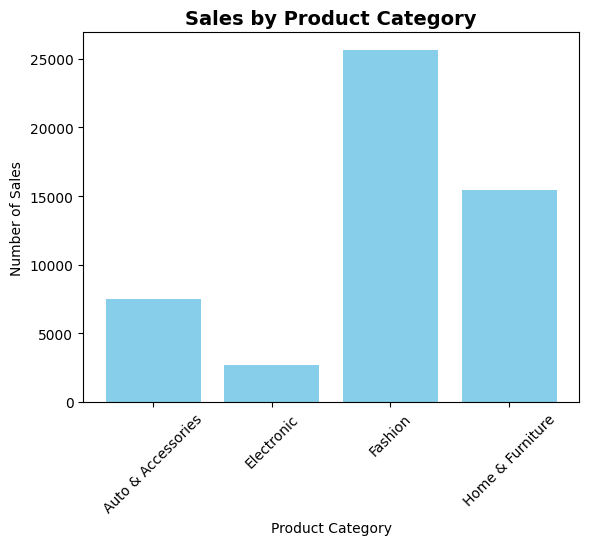

In [ ]:
grouped_by_category = sales_data.groupby('product_category')["sales"].count()

plt.bar(grouped_by_category.index, grouped_by_category.values, color="skyblue")
plt.title("Sales by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Product Category")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.show()


Найбільше продажів у категорія - Мода.
Найменше продажів у категорії - Електроніка

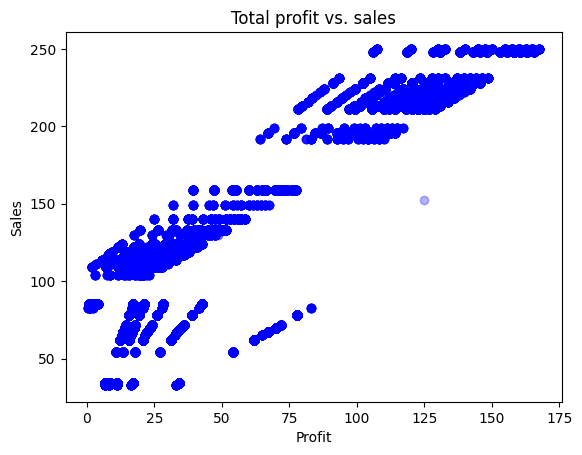

In [ ]:
plt.scatter(sales_data['profit'], sales_data['sales'], color="blue", alpha=0.3)
plt.title("Total profit vs. sales")
plt.xlabel("Profit")
plt.ylabel("Sales")
plt.show()


На графіку спостерігаємо пряму залежність, тобто зі зростанням продажів зростає і дохід

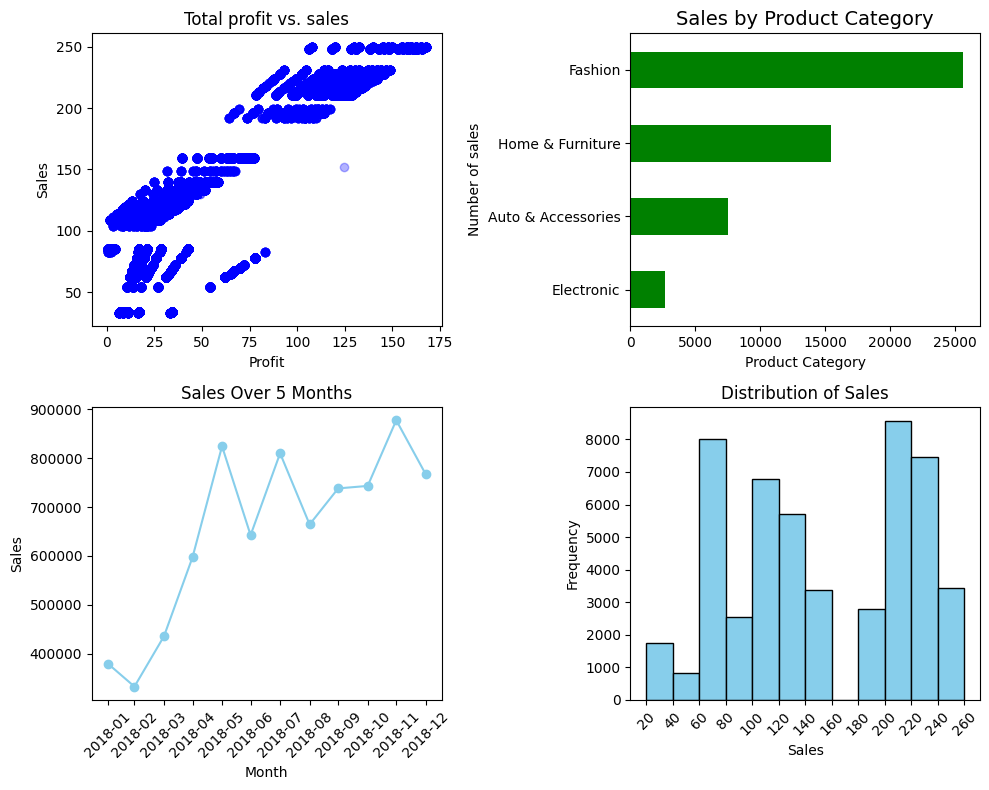

In [ ]:
import matplotlib.dates as mdates
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# First subplot - Scatter plot of total_bill vs tip
ax[0, 0].scatter(sales_data['profit'], sales_data['sales'], color="blue", alpha=0.3)
ax[0, 0].set_title("Total profit vs. sales")
ax[0, 0].set_xlabel("Profit")
ax[0, 0].set_ylabel("Sales")


sales_data.groupby('product_category', observed=False)['sales'].count().sort_values().plot(
    kind="barh", ax=ax[0, 1], color="green"
)
ax[0, 1].set_title("Sales by Product Category", fontsize=14)
ax[0, 1].set_xlabel("Product Category")
ax[0, 1].set_ylabel("Number of sales")


monthly_sales = sales_data.groupby(pd.Grouper(key="order_date", freq="ME"))['sales'].sum()
ax[1, 0].plot(monthly_sales.index, monthly_sales.values, marker='o', color="skyblue", linestyle='-')
ax[1, 0].set_xticks(monthly_sales.index)
ax[1, 0].set_xticklabels([d.strftime("%Y-%m") for d in monthly_sales.index], rotation=45)
ax[1, 0].set_title("Sales Over 5 Months")
ax[1, 0].set_xlabel("Month")
ax[1, 0].set_ylabel("Sales")

sales = sales_data["sales"]
bin_edges = np.arange(sales.min() - 13, sales.max() + 20, 20)
ax[1, 1].hist(sales_data["sales"], bins=bin_edges, color="skyblue", edgecolor="black")
ax[1, 1].set_title("Distribution of Sales")
ax[1, 1].set_xlabel("Sales")
ax[1, 1].set_ylabel("Frequency")
plt.xticks(bin_edges, rotation=45)

plt.tight_layout()

# Show plots
plt.show()
